In [13]:
import tifffile as tiff
import numpy as np
from pathlib import Path
import pandas as pd
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
root = Path("/Volumes/HELHEIM/analyzed_data/heat_shock/raw_data_KT/20260114_RNAscope_bactin-561_Nos-633_Vasa-488_Tg24_12hpf_heat-shock_vs_ctrl")

In [15]:
list_of_sample_paths = [pth for pth in root.iterdir() if pth.is_dir() and not pth.name.startswith('.')]
for sample_path in list_of_sample_paths:
    sample_dict = {}
    uid, filename = sample_path.name.split('__')
    condition, sample_number = filename.split('-')


In [16]:
def compute_masks(seg_cell, seg_nucleus, seg_granule, safety_margin=2):
    # Create binary masks
    cell_mask = seg_cell > 0
    nucleus_mask = seg_nucleus > 0
    granule_mask = seg_granule > 0

    # Only consider granules within cells
    granule_mask = granule_mask & cell_mask

    # Only consider nucleus within cells
    nucleus_mask = nucleus_mask & cell_mask

    # Cytoplasm mask is cell minus nucleus and granules with safety margin
    nucleus_granule_mask = nucleus_mask | granule_mask
    distance_map = distance_transform_edt(~nucleus_granule_mask)
    cytoplasm_mask = cell_mask & (distance_map > safety_margin)
    return cell_mask, nucleus_mask, granule_mask, cytoplasm_mask

In [17]:
sample_path = list_of_sample_paths[0]

In [21]:
measurement_dicts = []
for sample_path in list_of_sample_paths:
    print(f'Processing sample: {sample_path.name}')
    save_figures = False  # Set to True to save figures for each sample


    sample_dict = {}

    uid, filename = sample_path.name.split('__')
    condition, sample_number = filename.split('-')

    sample_dict.update({
        'sample_path': sample_path,
        'uid': uid,
        'condition': condition,
        'sample_number': sample_number,
        'is_PGC': False if 'soma' in condition.lower() else True,
        "is_heatshock": True if 'heat' in condition.lower() else False
    })

    img_rna_actin_path = sample_path / "raw" / "bact_rna.tiff"
    img_granule_path = sample_path / "raw" / "granule.tiff"
    img_rna_nanos_path = sample_path / "raw" / "nos_rna.tiff"
    img_nucleus_path = sample_path / "raw" / "nucleus.tiff"

    seg_granule_path = sample_path / "segmentations" / "granule.tiff"
    seg_nucleus_path = sample_path / "segmentations" / "nucleus.tiff"
    seg_cell_path = sample_path / "segmentations" / "cell.tiff"


    img_rna_actin = tiff.imread(img_rna_actin_path)
    img_granule = tiff.imread(img_granule_path)
    img_rna_nanos = tiff.imread(img_rna_nanos_path)
    img_nucleus = tiff.imread(img_nucleus_path)

    img_seg_granule = tiff.imread(seg_granule_path)
    img_seg_nucleus = tiff.imread(seg_nucleus_path)
    img_seg_cell = tiff.imread(seg_cell_path)

    mask_cell, mask_nucleus, mask_granule, mask_cytoplasm = compute_masks(
        img_seg_cell, img_seg_nucleus, img_seg_granule, safety_margin=2)

    # Measure and store relevant intensies
    areas_to_measure = {
        "cytoplasm": mask_cytoplasm,
        "nucleus": mask_nucleus,
        "granules": mask_granule,
        "cell": mask_cell
    }

    images_to_measure = {
        "bactin_rna": img_rna_actin,
        "nanos_rna": img_rna_nanos,
        "granules": img_granule
    }

    for area_name, area_mask in areas_to_measure.items():
        for image_name, image in images_to_measure.items():
            mean_intensity = np.mean(image[area_mask])
            total_intensity = np.sum(image[area_mask])
            area_size = np.sum(area_mask)
            measurement_dict = sample_dict.copy()
            measurement_dict.update({
                "area_name": area_name,
                "marker_name": image_name,
                "mean_intensity": mean_intensity,
                "total_intensity": total_intensity,
                "area_size": area_size
            })
            measurement_dicts.append(measurement_dict)

        if save_figures:
            # Plot raw images and segmentations
            figs, axs = plt.subplots(2, 4, figsize=(10, 5))
            # Top row: raw images
            axs[0, 0].imshow(img_nucleus, cmap='gray')
            axs[0, 0].set_title('Nucleus')
            axs[0, 1].imshow(img_granule, cmap='gray')
            axs[0, 1].set_title('Granules')
            axs[0, 2].imshow(img_rna_actin, cmap='gray')
            axs[0, 2].set_title('Bactin RNA')
            axs[0, 3].imshow(img_rna_nanos, cmap='gray')
            axs[0, 3].set_title('Nanos RNA')

            # Bottom row: segmentations
            axs[1, 0].imshow(img_seg_nucleus, cmap='gray')
            axs[1, 0].set_title('Nucleus Segmentation')
            axs[1, 1].imshow(img_seg_granule, cmap='gray')
            axs[1, 1].set_title('Granule Segmentation')
            axs[1, 2].imshow(img_seg_cell, cmap='gray')
            axs[1, 2].set_title('Cell Segmentation')
            axs[1, 3].imshow(mask_cytoplasm, cmap='gray')
            axs[1, 3].set_title('Cytoplasm Mask')
            plt.tight_layout()
            for ax in axs.flat:
                ax.axis('off')
            figs.suptitle(f'Sample: {sample_path.name}', y=1.02)
            figs.savefig(sample_path / f'{sample_path.name}_overview.png', bbox_inches='tight')
            plt.close(figs)



Processing sample: 29b45ed029d249d096395450efac9500__control-11
Processing sample: 7339c14b28934028b2fbca40e9a6a17d__control-13
Processing sample: e5a0d9fddc074c138de9e4d603607e4f__control-14
Processing sample: 1219712ed584489f9ec9f424d78949f4__control-16
Processing sample: b62e85bac21c4e2f814080bde751646d__control-18
Processing sample: 0062b885e11647929eaaceca7ba06389__control-19
Processing sample: ef09a61af99c46b185e5de75604a736b__control-20
Processing sample: f0b95e49bce74e8796f1a5f300ef73a6__control-4
Processing sample: 76c5815ac77443468131deb54e8d8f16__control-5
Processing sample: 45e51f1534d84d52a5d05d4aa3a80915__control-7
Processing sample: 9b0a5c7891c9478797878361480627cf__control-9
Processing sample: bf224089d813459d93b48195f75532bb__heatshock-1
Processing sample: ceb7cb65249d446391fa6dc5ed64f21f__heatshock-11
Processing sample: 1cd6cad3c6ce4d1aa938ba1b26e5b562__heatshock-12b
Processing sample: cf1441a55f3b47c48fa5858d26d5878a__heatshock-13
Processing sample: 417126e9d2db4cc1a

In [22]:
df_main = pd.DataFrame(measurement_dicts)

In [23]:
df_main

,sample_path,uid,condition,sample_number,is_PGC,is_heatshock,area_name,marker_name,mean_intensity,total_intensity,area_size
0,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,bactin_rna,1518.902797,65988732,43445
1,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,nanos_rna,285.076004,12385127,43445
2,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,granules,1952.838808,84841082,43445
3,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,nucleus,bactin_rna,1724.388144,42063000,24393
4,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,nucleus,nanos_rna,331.517690,8086711,24393
...,...,...,...,...,...,...,...,...,...,...,...
727,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,granules,nanos_rna,182.203033,1021248,5605
728,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,granules,granules,7543.347547,42280463,5605
729,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,cell,bactin_rna,2276.540065,526622907,231326
730,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,cell,nanos_rna,183.510734,42450804,231326


In [24]:
# Calculate per cell ratios of cytoplasm to granule intensities for all marker_names
df_cytoplasm_granule_ratio = df_main.pivot_table(
    index=['uid', 'condition', 'sample_number', 'is_PGC', 'is_heatshock', 'marker_name'],
    columns='area_name',
    values='mean_intensity'
).reset_index()
df_cytoplasm_granule_ratio['cytoplasm_to_granule_ratio'] = (
    df_cytoplasm_granule_ratio['cytoplasm'] / df_cytoplasm_granule_ratio['granules']
)


In [25]:
df_cytoplasm_granule_ratio

area_name,uid,condition,sample_number,is_PGC,is_heatshock,marker_name,cell,cytoplasm,granules,nucleus,cytoplasm_to_granule_ratio
0,0062b885e11647929eaaceca7ba06389,control,19,True,False,bactin_rna,4756.127832,3712.489484,18764.290096,2783.510312,0.197849
1,0062b885e11647929eaaceca7ba06389,control,19,True,False,granules,4817.854593,3232.438241,21746.999796,4392.929364,0.148638
2,0062b885e11647929eaaceca7ba06389,control,19,True,False,nanos_rna,1602.849193,973.211216,8633.537090,937.476303,0.112725
3,009cdd5831664ed9a0ce8e9a8aa4db72,somaHeatshock,9,False,True,bactin_rna,1894.109365,2206.697408,2985.195617,1431.575675,0.739214
4,009cdd5831664ed9a0ce8e9a8aa4db72,somaHeatshock,9,False,True,granules,1281.176166,1126.254121,7469.854593,1186.609004,0.150773
...,...,...,...,...,...,...,...,...,...,...,...
178,f66cfcdcb39a4d31a596e26bc4202e1b,heatshock,10,True,True,granules,14478.071298,6982.450568,38707.223372,6075.334929,0.180391
179,f66cfcdcb39a4d31a596e26bc4202e1b,heatshock,10,True,True,nanos_rna,7125.838677,2018.973820,21759.136740,3241.155433,0.092787
180,f849b09d8946486983728c54ee3d1223,heatshock,18,True,True,bactin_rna,5816.589189,4370.816467,23893.806230,2356.057103,0.182927
181,f849b09d8946486983728c54ee3d1223,heatshock,18,True,True,granules,6911.625774,5260.054238,28664.786005,2620.798563,0.183502


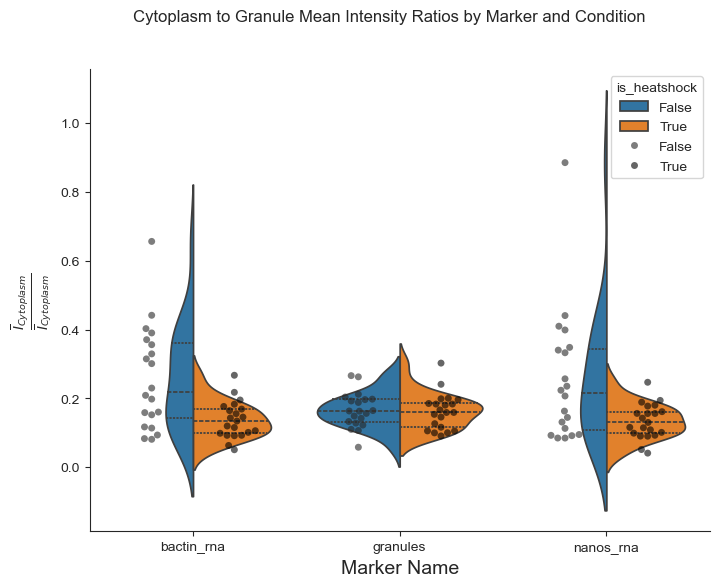

In [39]:
sns.set_style(style="ticks")
fig_cyto_gran, ax_cyto_gran = plt.subplots(figsize=(8, 6))
fig_cyto_gran.suptitle('Cytoplasm to Granule Mean Intensity Ratios by Marker and Condition')
sns.violinplot(data=df_cytoplasm_granule_ratio.query("is_PGC == True"),
               x='marker_name',
               y='cytoplasm_to_granule_ratio',
               hue='is_heatshock',
               split=True,
               inner='quart',
               ax=ax_cyto_gran)
sns.swarmplot(data=df_cytoplasm_granule_ratio.query("is_PGC == True"),
              x='marker_name',
              y='cytoplasm_to_granule_ratio',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_cyto_gran)
ax_cyto_gran.set_ylabel(r"$\frac{\overline{I}_{Cytoplasm}}{\overline{I}_{Cytoplasm}}$", fontsize=14)
ax_cyto_gran.set_xlabel("Marker Name", fontsize=14)
sns.despine()

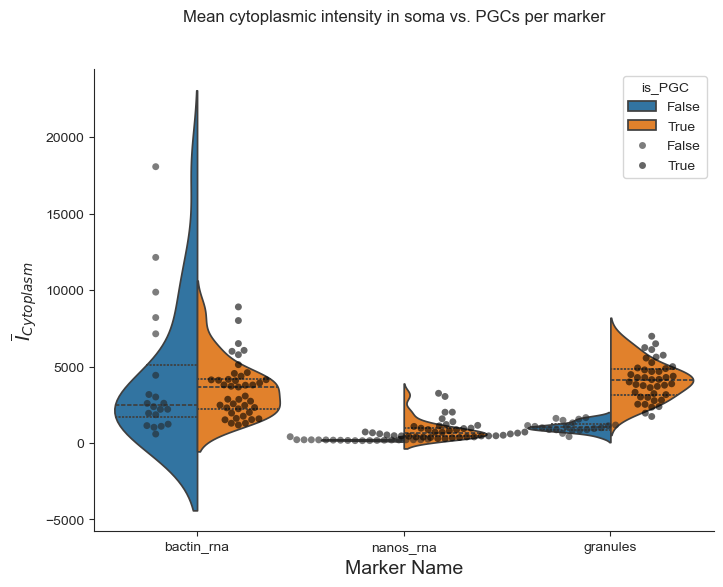

In [41]:
fig_soma_cyto, ax_soma_cyto = plt.subplots(figsize=(8, 6))
fig_soma_cyto.suptitle('Mean cytoplasmic intensity in soma vs. PGCs per marker')
sns.violinplot(data=df_main.query("area_name == 'cytoplasm'"),
               x='marker_name',
               y='mean_intensity',
               hue='is_PGC',
               split=True,
               inner='quart',
               ax=ax_soma_cyto,
               density_norm="width")
sns.swarmplot(data=df_main.query("area_name == 'cytoplasm'"),
              x='marker_name',
              y='mean_intensity',
              hue='is_PGC',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_soma_cyto)
ax_soma_cyto.set_ylabel(r"$\overline{I}_{Cytoplasm}$", fontsize=14)
ax_soma_cyto.set_xlabel("Marker Name", fontsize=14)
sns.despine()